In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


In [2]:
df = pd.read_csv('diabetes_prediction_dataset.csv')

df.head(10)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
5,Female,20.0,0,0,never,27.32,6.6,85,0
6,Female,44.0,0,0,never,19.31,6.5,200,1
7,Female,79.0,0,0,No Info,23.86,5.7,85,0
8,Male,42.0,0,0,never,33.64,4.8,145,0
9,Female,32.0,0,0,never,27.32,5.0,100,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB


In [6]:
df.describe(include='all')

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000,100000.000000,100000.00000,100000.000000,100000,100000.000000,100000.000000,100000.000000,100000.000000
unique,3,NaN,NaN,NaN,6,NaN,NaN,NaN,NaN
top,Female,NaN,NaN,NaN,No Info,NaN,NaN,NaN,NaN
freq,58552,NaN,NaN,NaN,35816,NaN,NaN,NaN,NaN
mean,NaN,41.885856,0.07485,0.039420,NaN,27.320767,5.527507,138.058060,0.085000
std,NaN,22.516840,0.26315,0.194593,NaN,6.636783,1.070672,40.708136,0.278883
min,NaN,0.080000,0.00000,0.000000,NaN,10.010000,3.500000,80.000000,0.000000
25%,NaN,24.000000,0.00000,0.000000,NaN,23.630000,4.800000,100.000000,0.000000
50%,NaN,43.000000,0.00000,0.000000,NaN,27.320000,5.800000,140.000000,0.000000
75%,NaN,60.000000,0.00000,0.000000,NaN,29.580000,6.200000,159.000000,0.000000


In [7]:
nulos = df.isnull().sum()
pct_nulos = (df.isnull().sum() / len(df) * 100).round(2)

resumo_nulos = pd.DataFrame({
    'Valores Nulos': nulos,
    '% do Total': pct_nulos
})

print(resumo_nulos)
print(f'\nTotal de valores nulos: {df.isnull().sum().sum()}')

                     Valores Nulos  % do Total
gender                           0         0.0
age                              0         0.0
hypertension                     0         0.0
heart_disease                    0         0.0
smoking_history                  0         0.0
bmi                              0         0.0
HbA1c_level                      0         0.0
blood_glucose_level              0         0.0
diabetes                         0         0.0

Total de valores nulos: 0


In [ ]:
duplicatas = df.duplicated().sum()
print(f'Registros duplicados: {duplicatas}')
print(f'Representam {duplicatas/len(df)*100:.2f}% do dataset')


df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(10)

Registros duplicados: 3854
Representam 3.85% do dataset


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
47708,Female,2.0,0,0,No Info,27.32,5.0,158,0
59468,Female,2.0,0,0,No Info,27.32,5.0,158,0
62073,Female,2.0,0,0,No Info,27.32,6.0,85,0
67439,Female,2.0,0,0,No Info,27.32,6.0,85,0
23617,Female,2.0,0,0,No Info,27.32,6.0,145,0
67234,Female,2.0,0,0,No Info,27.32,6.0,145,0
90685,Female,2.0,0,0,No Info,27.32,6.2,145,0
97294,Female,2.0,0,0,No Info,27.32,6.2,145,0
46785,Female,2.0,0,0,No Info,27.32,6.5,155,0
89701,Female,2.0,0,0,No Info,27.32,6.5,155,0


In [26]:
df = df.drop_duplicates(keep='first').reset_index(drop=True)

In [24]:
print(df['gender'].value_counts())


gender
Female    58552
Male      41430
Name: count, dtype: int64


In [25]:
print(f'\nProporção de "Other": {(df["gender"] == "Other").sum() / len(df) * 100:.4f}%')


Proporção de "Other": 0.0000%


In [22]:
df = df[df['gender'] != 'Other'].reset_index(drop=True)

print('Após remoção:')
print(df['gender'].value_counts())


Após remoção:
gender
Female    58552
Male      41430
Name: count, dtype: int64


smoking_history
never          34395
No Info        32881
former          9299
current         9197
not current     6359
ever            3997
Name: count, dtype: int64


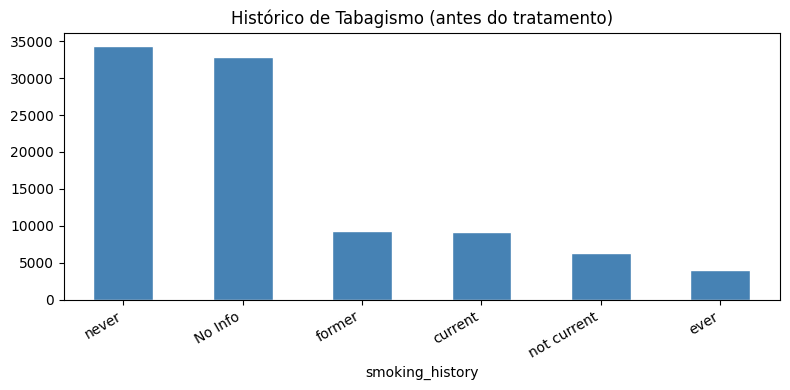

In [27]:
print(df['smoking_history'].value_counts())

df['smoking_history'].value_counts().plot(
    kind='bar', figsize=(8, 4), color='steelblue', edgecolor='white',
    title='Histórico de Tabagismo (antes do tratamento)'
)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [29]:
mapeamento_smoking = {
    'No Info'     : 'unknown',   
    'never'       : 'never',
    'current'     : 'current',
    'former'      : 'former',
    'ever'        : 'current',    
    'not current' : 'former'     
}

df['smoking_history'] = df['smoking_history'].map(mapeamento_smoking)


print(df['smoking_history'].value_counts())

smoking_history
never      34395
former     15658
current    13194
Name: count, dtype: int64


In [30]:
df['age'].value_counts()

age
80.00    4932
51.00    1566
47.00    1509
48.00    1508
53.00    1497
         ... 
1.00       83
0.48       83
0.40       66
0.16       59
0.08       36
Name: count, Length: 102, dtype: int64

In [35]:
print(f'Registros com age menor que 2 anos: {(df["age"] < 2).sum()}')
print(df[df['age'] < 2]['age'].value_counts().sort_index())

Registros com age menor que 2 anos: 0
Series([], Name: count, dtype: int64)


In [33]:
df = df[df['age'] >= 2].reset_index(drop=True)

print(f'Shape após remoção: {df.shape}')
print(f'Idade mínima agora: {df["age"].min()}')

Shape após remoção: (94032, 9)
Idade mínima agora: 2.0


In [37]:
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 - Q1

print(f'Q1={Q1:.2f} | Q3={Q3:.2f} | IQR={IQR:.2f}')
print(f'Limite superior IQR: {Q3 + 1.5 * IQR:.2f}')
print(f'Outliers detectados: {((df["bmi"] < Q1 - 1.5*IQR) | (df["bmi"] > Q3 + 1.5*IQR)).sum()}')

Q1=23.72 | Q3=30.00 | IQR=6.28
Limite superior IQR: 39.42
Outliers detectados: 5547


In [38]:
p01 = df['bmi'].quantile(0.01)
p99 = df['bmi'].quantile(0.99)

print(f'Percentil 1%: {p01:.2f} | Percentil 99%: {p99:.2f}')

df['bmi'] = df['bmi'].clip(lower=p01, upper=p99)

print(f'BMI máximo após winsorização: {df["bmi"].max():.2f}')
print(f'BMI mínimo após winsorização: {df["bmi"].min():.2f}')

Percentil 1%: 14.87 | Percentil 99%: 49.07
BMI máximo após winsorização: 49.07
BMI mínimo após winsorização: 14.87


In [39]:
print(f'Outliers detectados: {((df["bmi"] < Q1 - 1.5*IQR) | (df["bmi"] > Q3 + 1.5*IQR)).sum()}')

Outliers detectados: 5061


C:\Users\felip\AppData\Local\Temp\ipykernel_3844\2103488376.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()


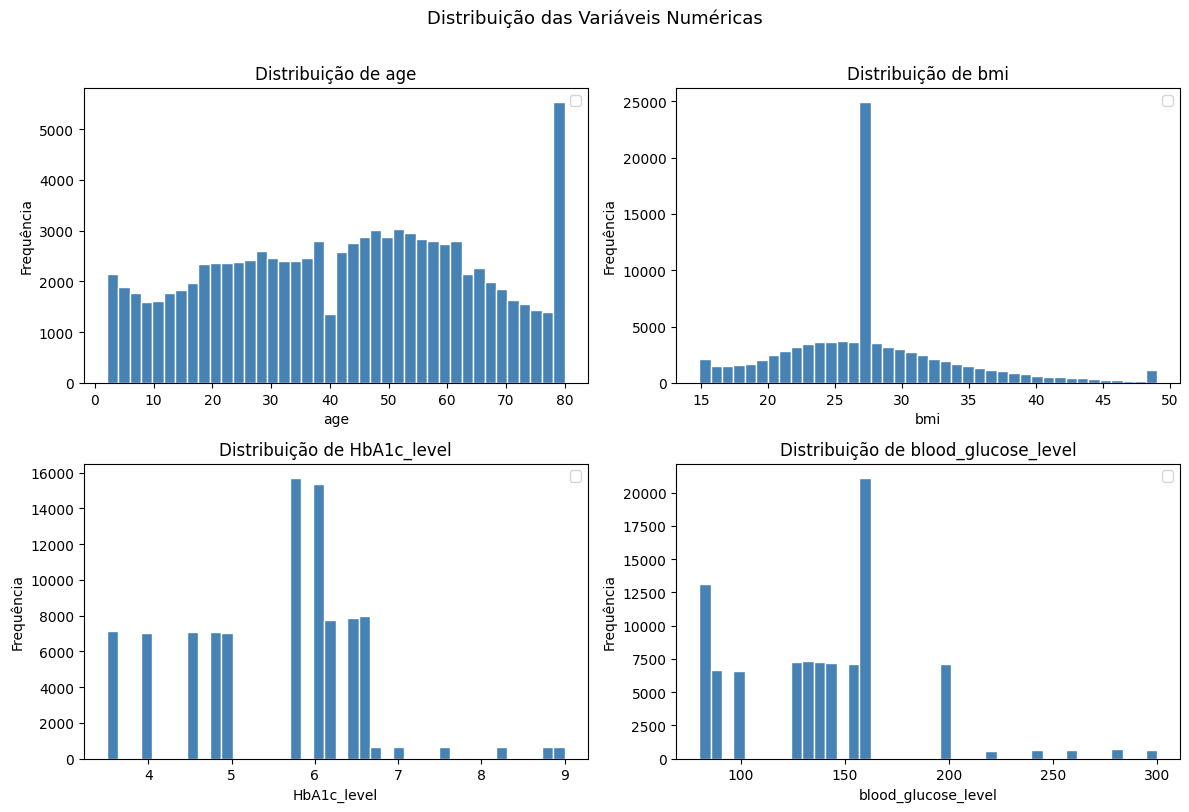

In [42]:
numericas = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(numericas):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribuição de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequência')
    axes[i].legend()

plt.suptitle('Distribuição das Variáveis Numéricas', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

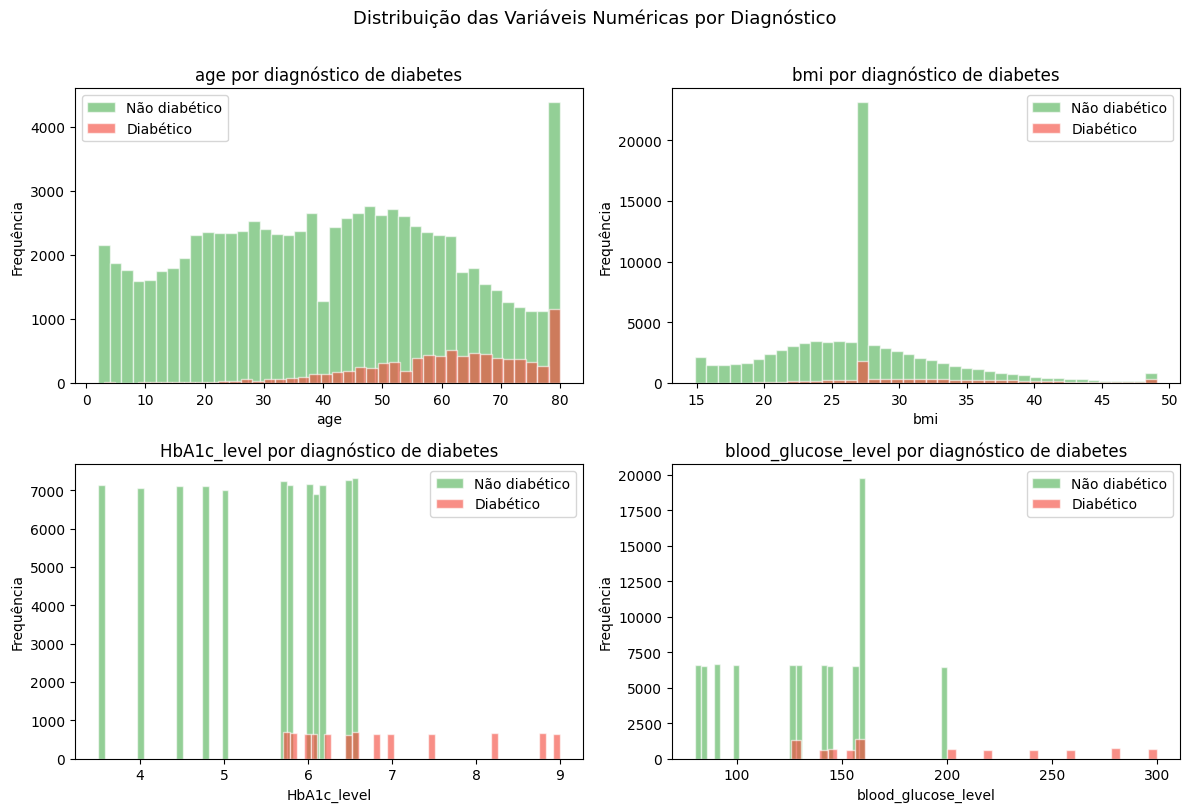

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(numericas):
    for label, color in zip([0, 1], ['#4CAF50', '#F44336']):
        subset = df[df['diabetes'] == label][col]
        axes[i].hist(subset, bins=40, alpha=0.6, color=color,
                     edgecolor='white', label=f'{"Diabético" if label else "Não diabético"}')
    axes[i].set_title(f'{col} por diagnóstico de diabetes')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequência')
    axes[i].legend()

plt.suptitle('Distribuição das Variáveis Numéricas por Diagnóstico', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

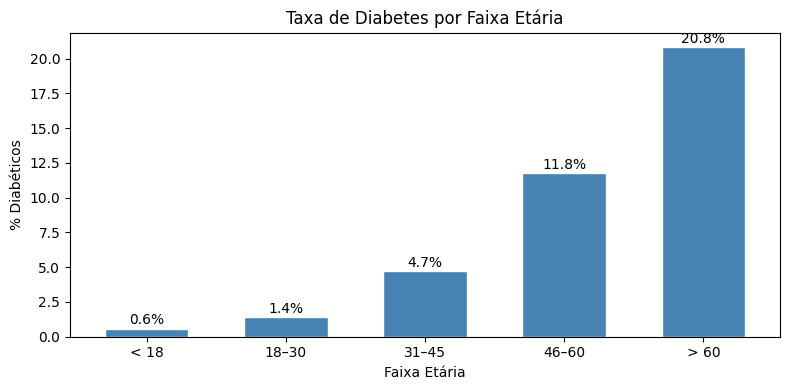

In [44]:
df['faixa_etaria'] = pd.cut(df['age'],
                             bins=[0, 18, 30, 45, 60, 80],
                             labels=['< 18', '18–30', '31–45', '46–60', '> 60'])

taxa_idade = df.groupby('faixa_etaria', observed=True)['diabetes'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))
taxa_idade.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white', width=0.6)
ax.set_title('Taxa de Diabetes por Faixa Etária')
ax.set_xlabel('Faixa Etária')
ax.set_ylabel('% Diabéticos')
ax.set_xticklabels(taxa_idade.index, rotation=0)
for i, v in enumerate(taxa_idade):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

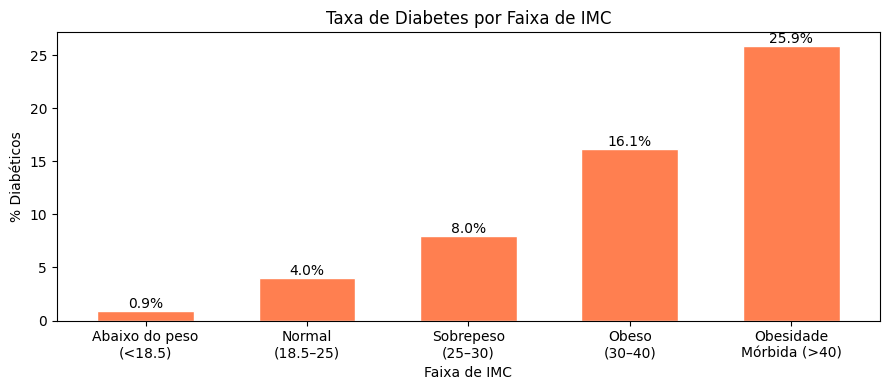

In [45]:
df['faixa_bmi'] = pd.cut(df['bmi'],
                          bins=[0, 18.5, 25, 30, 40, 100],
                          labels=['Abaixo do peso\n(<18.5)',
                                  'Normal\n(18.5–25)',
                                  'Sobrepeso\n(25–30)',
                                  'Obeso\n(30–40)',
                                  'Obesidade\nMórbida (>40)'])

taxa_bmi = df.groupby('faixa_bmi', observed=True)['diabetes'].mean() * 100

fig, ax = plt.subplots(figsize=(9, 4))
taxa_bmi.plot(kind='bar', ax=ax, color='coral', edgecolor='white', width=0.6)
ax.set_title('Taxa de Diabetes por Faixa de IMC')
ax.set_xlabel('Faixa de IMC')
ax.set_ylabel('% Diabéticos')
ax.set_xticklabels(taxa_bmi.index, rotation=0)
for i, v in enumerate(taxa_bmi):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

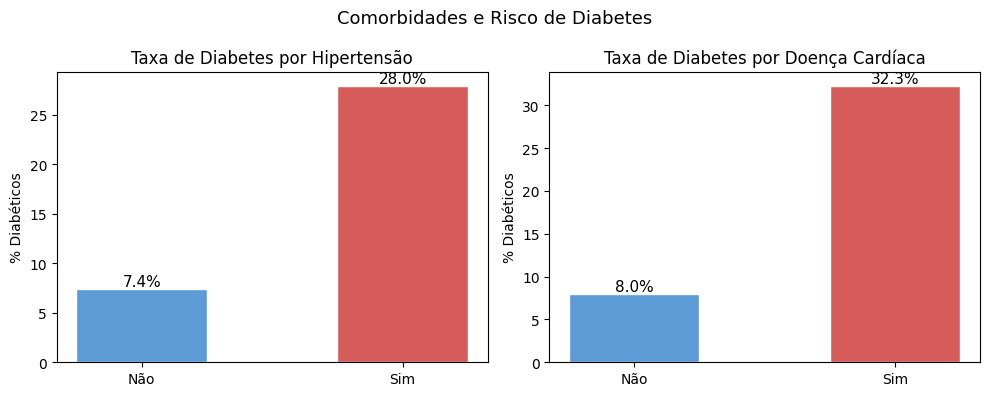

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col, titulo in zip(axes,
                            ['hypertension', 'heart_disease'],
                            ['Hipertensão', 'Doença Cardíaca']):
    taxa = df.groupby(col)['diabetes'].mean() * 100
    ax.bar(['Não', 'Sim'], taxa.values,
           color=['#5C9BD6', '#D65C5C'], edgecolor='white', width=0.5)
    ax.set_title(f'Taxa de Diabetes por {titulo}')
    ax.set_ylabel('% Diabéticos')
    for i, v in enumerate(taxa.values):
        ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=11)

plt.suptitle('Comorbidades e Risco de Diabetes', fontsize=13)
plt.tight_layout()
plt.show()

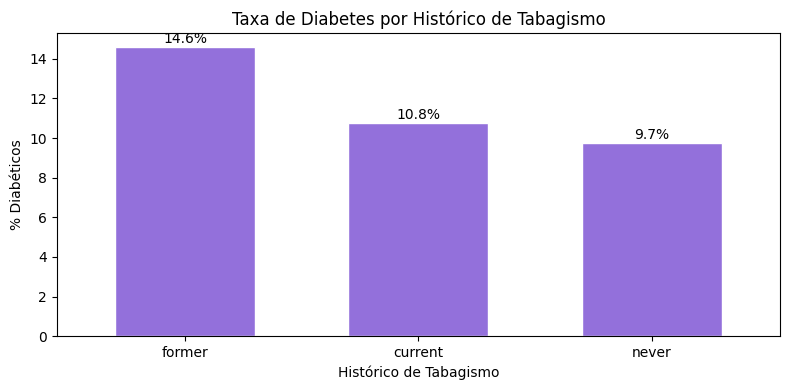

In [47]:
taxa_smoking = df.groupby('smoking_history')['diabetes'].mean() * 100
taxa_smoking = taxa_smoking.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
taxa_smoking.plot(kind='bar', ax=ax, color='mediumpurple', edgecolor='white', width=0.6)
ax.set_title('Taxa de Diabetes por Histórico de Tabagismo')
ax.set_xlabel('Histórico de Tabagismo')
ax.set_ylabel('% Diabéticos')
ax.set_xticklabels(taxa_smoking.index, rotation=0)
for i, v in enumerate(taxa_smoking):
    ax.text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

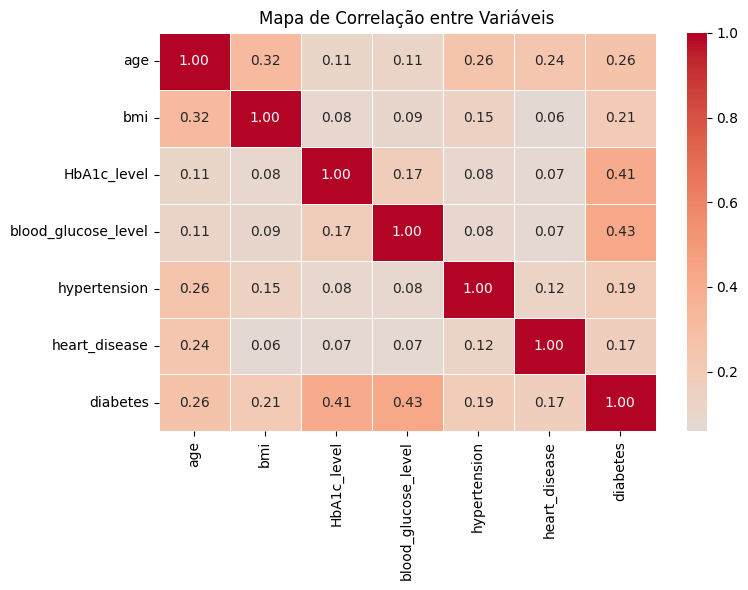

In [48]:
fig, ax = plt.subplots(figsize=(8, 6))

numericas_corr = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level',
                   'hypertension', 'heart_disease', 'diabetes']

corr = df[numericas_corr].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5,
            annot_kws={'size': 10})
ax.set_title('Mapa de Correlação entre Variáveis')
plt.tight_layout()
plt.show()

In [49]:
# Variável preditora escolhida: blood_glucose_level
# Variável alvo: diabetes (0 ou 1)

# Criar categoria de glicose baseada em limiar clínico
# < 126 mg/dL → Normal | >= 126 mg/dL → Elevada
df['glicose_alta'] = (df['blood_glucose_level'] >= 126).astype(int)

print('Distribuição de glicose_alta:')
print(df['glicose_alta'].value_counts())
print(df['glicose_alta'].value_counts(normalize=True).round(4))

Distribuição de glicose_alta:
glicose_alta
1    67658
0    26374
Name: count, dtype: int64
glicose_alta
1    0.7195
0    0.2805
Name: proportion, dtype: float64


In [50]:
total = len(df)

p_diabetico     = (df['diabetes'] == 1).sum() / total
p_nao_diabetico = (df['diabetes'] == 0).sum() / total

print('=== Probabilidades a Priori ===')
print(f'  P(diabético)     = {p_diabetico:.4f}  ({p_diabetico*100:.2f}%)')
print(f'  P(não diabético) = {p_nao_diabetico:.4f}  ({p_nao_diabetico*100:.2f}%)')

=== Probabilidades a Priori ===
  P(diabético)     = 0.0902  (9.02%)
  P(não diabético) = 0.9098  (90.98%)


In [51]:
# P(glicose alta | diabético)
p_gli_alta_dado_diab     = df[df['diabetes'] == 1]['glicose_alta'].mean()
p_gli_alta_dado_nao_diab = df[df['diabetes'] == 0]['glicose_alta'].mean()

p_gli_norm_dado_diab     = 1 - p_gli_alta_dado_diab
p_gli_norm_dado_nao_diab = 1 - p_gli_alta_dado_nao_diab

print('=== Verossimilhanças ===')
print(f'\n  P(glicose alta | diabético)     = {p_gli_alta_dado_diab:.4f}  ({p_gli_alta_dado_diab*100:.2f}%)')
print(f'  P(glicose alta | não diabético) = {p_gli_alta_dado_nao_diab:.4f}  ({p_gli_alta_dado_nao_diab*100:.2f}%)')
print(f'\n  P(glicose normal | diabético)     = {p_gli_norm_dado_diab:.4f}  ({p_gli_norm_dado_diab*100:.2f}%)')
print(f'  P(glicose normal | não diabético) = {p_gli_norm_dado_nao_diab:.4f}  ({p_gli_norm_dado_nao_diab*100:.2f}%)')

=== Verossimilhanças ===

  P(glicose alta | diabético)     = 1.0000  (100.00%)
  P(glicose alta | não diabético) = 0.6917  (69.17%)

  P(glicose normal | diabético)     = 0.0000  (0.00%)
  P(glicose normal | não diabético) = 0.3083  (30.83%)


In [52]:
# P(glicose alta) — probabilidade marginal, independente da classe
p_gli_alta  = (df['glicose_alta'] == 1).sum() / total
p_gli_norm  = 1 - p_gli_alta

print('=== Probabilidade Total (evidência) ===')
print(f'  P(glicose alta)   = {p_gli_alta:.4f}  ({p_gli_alta*100:.2f}%)')
print(f'  P(glicose normal) = {p_gli_norm:.4f}  ({p_gli_norm*100:.2f}%)')

=== Probabilidade Total (evidência) ===
  P(glicose alta)   = 0.7195  (71.95%)
  P(glicose normal) = 0.2805  (28.05%)


In [53]:
# P(diabético | glicose alta)
p_diab_dado_gli_alta = (p_gli_alta_dado_diab * p_diabetico) / p_gli_alta

# P(diabético | glicose normal)
p_diab_dado_gli_norm = (p_gli_norm_dado_diab * p_diabetico) / p_gli_norm

print('=== Probabilidades a Posteriori ===')
print(f'\n  P(diabético | glicose ALTA)   = {p_diab_dado_gli_alta:.4f}  ({p_diab_dado_gli_alta*100:.2f}%)')
print(f'  P(diabético | glicose NORMAL) = {p_diab_dado_gli_norm:.4f}  ({p_diab_dado_gli_norm*100:.2f}%)')

=== Probabilidades a Posteriori ===

  P(diabético | glicose ALTA)   = 0.1254  (12.54%)
  P(diabético | glicose NORMAL) = 0.0000  (0.00%)


In [56]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encoding das variáveis categóricas
df_model = df.copy()

le_gender  = LabelEncoder()
le_smoking = LabelEncoder()

df_model['gender']          = le_gender.fit_transform(df_model['gender'])
df_model['smoking_history'] = le_smoking.fit_transform(df_model['smoking_history'])

# Features e variável alvo
X = df_model[['age', 'bmi', 'HbA1c_level', 'blood_glucose_level',
              'gender', 'smoking_history', 'hypertension', 'heart_disease']]
y = df_model['diabetes']

# Split treino/teste — 80/20 com estratificação (por causa do desbalanceamento)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Treino: {X_train.shape[0]} registros')
print(f'Teste:  {X_test.shape[0]} registros')

Treino: 75225 registros
Teste:  18807 registros


In [58]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Treinar
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

# Avaliar
y_pred_dt = dt.predict(X_test)

print('=== Árvore de Decisão ===\n')
print(classification_report(y_test, y_pred_dt,
      target_names=['Não diabético', 'Diabético']))

=== Árvore de Decisão ===

               precision    recall  f1-score   support

Não diabético       0.97      1.00      0.98     17111
    Diabético       1.00      0.68      0.81      1696

     accuracy                           0.97     18807
    macro avg       0.98      0.84      0.90     18807
 weighted avg       0.97      0.97      0.97     18807



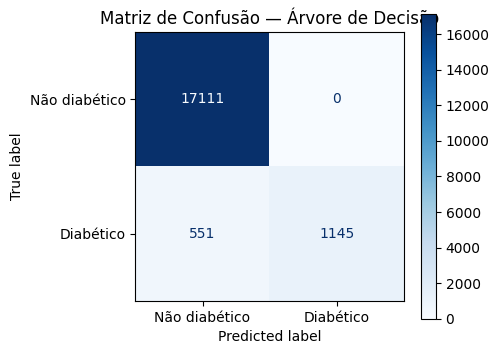

In [ ]:

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_dt),
                       display_labels=['Não diabético', 'Diabético']).plot(ax=ax, cmap='Blues')
ax.set_title('Matriz de Confusão — Árvore de Decisão')
plt.tight_layout()
plt.show()

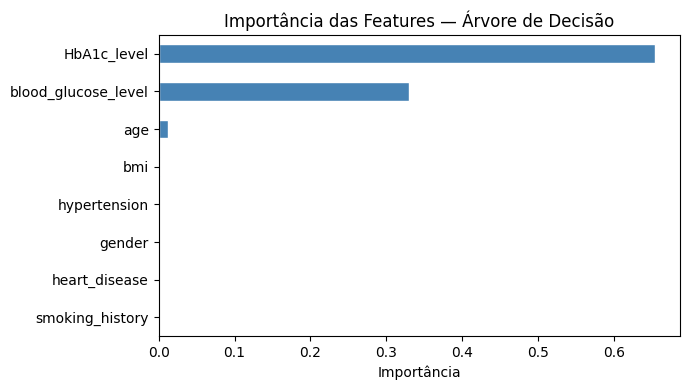

In [60]:

importancias = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
importancias.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Importância das Features — Árvore de Decisão')
ax.set_xlabel('Importância')
plt.tight_layout()
plt.show()

In [61]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# KNN é sensível à escala — normalizar antes
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Treinar
knn = KNeighborsClassifier(n_neighbors=11)
knn.fit(X_train_scaled, y_train)

# Avaliar
y_pred_knn = knn.predict(X_test_scaled)

print('=== KNN (k=11) ===\n')
print(classification_report(y_test, y_pred_knn,
      target_names=['Não diabético', 'Diabético']))

=== KNN (k=11) ===

               precision    recall  f1-score   support

Não diabético       0.96      1.00      0.98     17111
    Diabético       0.94      0.60      0.73      1696

     accuracy                           0.96     18807
    macro avg       0.95      0.80      0.86     18807
 weighted avg       0.96      0.96      0.96     18807



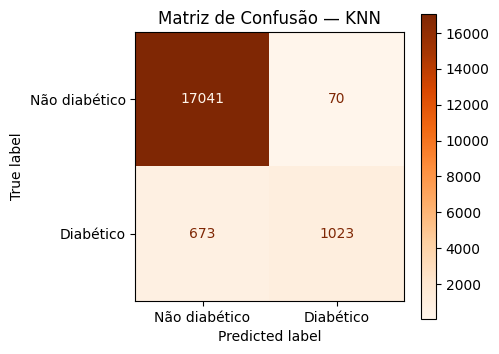

In [62]:
# Matriz de confusão
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_knn),
                       display_labels=['Não diabético', 'Diabético']).plot(ax=ax, cmap='Oranges')
ax.set_title('Matriz de Confusão — KNN')
plt.tight_layout()
plt.show()

In [63]:
df.to_csv('diabetes_limpo.csv', index=False)
print('\nDataset limpo salvo como: diabetes_limpo.csv')


Dataset limpo salvo como: diabetes_limpo.csv
